In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.metrics import balanced_accuracy_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

In [ ]:
SEED = 2210
WEATHER = ["MnDir(degT)", "MnSpd(mps)", "MnTemp(C)", "MnRH(%)",
           "Rain(mm)", "RadGlb(MJ/m2)", "Average W/m2", "Predicted BGT",
           "THI", "HLI", "Grazing HLI2"]
STATIC = ["NZDI", "Transport distance (calculated)",
          "lairage time (calculated)", "Age"]
TARGETS = ["live weight", "carcass weight", "price", "Total number of defects"]
BANDS = [(1, 4), (5, 10), (11, 20), (21, 30), (31, 60), (61, 90), (91, 120)]


# Set up experiments

In [ ]:
def prepare_data(root=Path("."), min_coverage=0.9):
    root = Path(root)
    beef = pd.read_csv(root / "data/beef_preprocessed.csv")
    old = pd.read_csv(root / "data/beef_weather_windows.csv")
    if len(beef) != len(old):
        raise ValueError("Animal and window tables differ in length. Regenerate together.")
    # These files have no shared animal ID: their existing positional join is retained.
    beef["kill date"] = pd.to_datetime(beef["kill date"], errors="raise")
    weather = pd.read_csv(root / "data/weather_preprocessed.csv", low_memory=False)
    weather["date"] = pd.to_datetime(weather["Date(NZST)"], errors="coerce").dt.normalize()
    weather[WEATHER] = weather[WEATHER].apply(pd.to_numeric, errors="coerce")
    weather = weather.dropna(subset=["date"]).sort_values("date")
    # Match the preparation notebook's fixed, whole-weather-series thresholds.
    thresholds = weather[WEATHER[1:]].quantile(0.9)
    additions, coverage = [], []
    for date in sorted(beef["kill date"].unique()):
        date = pd.Timestamp(date)
        feats = {"kill date": date}
        cov = {"kill date": date}
        for lo, hi in BANDS:
            sub = weather.loc[weather["date"].between(
                date - pd.Timedelta(days=hi), date - pd.Timedelta(days=lo))]
            daily = sub.groupby("date")[WEATHER].count().gt(0).sum()
            cov[f"coverage_{lo}_{hi}"] = float((daily / (hi - lo + 1)).min())
            if hi <= 60:
                continue
            for col in WEATHER:
                arr = sub[col].dropna().to_numpy(dtype=float)
                prefix = f"{col}__win{lo}_{hi}_"
                stats = ({"max": arr.max(), "min": arr.min(),
                          "diff": np.ptp(arr), "mean": arr.mean(), "std": arr.std()}
                         if len(arr) else dict.fromkeys(["max", "min", "diff", "mean", "std"], np.nan))
                feats.update({prefix + k: v for k, v in stats.items()})
                if col in thresholds:
                    thr = thresholds[col]
                    feats[prefix + f"above{round(thr, 2)}_count"] = (
                        int((arr > thr).sum()) if len(arr) else np.nan)
        additions.append(feats)
        coverage.append(cov)
    extra = pd.DataFrame(additions).set_index("kill date")
    cov = pd.DataFrame(coverage).set_index("kill date")
    cov["eligible"] = cov.min(axis=1).ge(min_coverage)
    data = beef.join(old).join(extra, on="kill date")
    data["eligible"] = data["kill date"].map(cov["eligible"])
    old_cols = [c for c in old if "__win" in c]
    feature_sets = {
        60: STATIC + old_cols,
        90: STATIC + old_cols + [c for c in extra if "__win61_90_" in c],
        120: STATIC + old_cols + list(extra.columns),
    }
    return data, feature_sets, cov

In [ ]:
def fit_horizons(data, feature_sets, targets=TARGETS, animal_types=("steer", "heifer"),
                 outer_folds=5, inner_folds=3, n_jobs=2, quick_smoke=False):
    rows, predictions, samples = [], [], []
    for animal in animal_types:
        for target in targets:
            candidate = data["Animal Type"].str.lower().eq(animal) & data[target].notna()
            subset = data.loc[candidate & data["eligible"]].copy()
            groups = subset["kill date"]
            samples.append({"animal_type": animal, "target": target,
                            "available_animals": int(candidate.sum()), "included_animals": len(subset),
                            "included_dates": groups.nunique(), "status": "evaluated"})
            if groups.nunique() < outer_folds:
                samples[-1]["status"] = "skipped: too few eligible dates"
                warnings.warn(f"Skipping {animal}, {target}: {groups.nunique()} eligible dates "
                              f"for {outer_folds} outer folds. Inspect coverage before changing the design.")
                continue
            classification = target == "Total number of defects"
            y = (subset[target] > 0).astype(int) if classification else subset[target]
            outer = list(GroupKFold(outer_folds, shuffle=True, random_state=SEED).split(subset, y, groups))
            for fold, (train, test) in enumerate(outer, 1):
                inner = list(GroupKFold(inner_folds, shuffle=True, random_state=SEED).split(
                    subset.iloc[train], y.iloc[train], groups.iloc[train]))
                if classification:
                    valid = y.iloc[test].nunique() == 2 and all(
                        y.iloc[train].iloc[idx].nunique() == 2 for pair in inner for idx in pair)
                    if not valid:
                        raise ValueError(f"Single-class grouped fold: {animal}, fold {fold}. "
                                         "Reduce folds or use a prespecified stratified grouped scheme.")
                for horizon, columns in feature_sets.items():
                    X = subset[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
                    estimator = (LogisticRegression(penalty="elasticnet", solver="saga",
                                 class_weight="balanced", max_iter=20000, random_state=SEED)
                                 if classification else ElasticNet(max_iter=50000, random_state=SEED))
                    pipeline = make_pipeline(SimpleImputer(strategy="median", keep_empty_features=True),
                                             StandardScaler(), estimator)
                    grid = ({"logisticregression__C": [0.01, 0.1, 1, 10],
                             "logisticregression__l1_ratio": [0.1, 0.5, 0.9]}
                            if classification else {"elasticnet__alpha": [0.01, 0.1, 1, 10],
                                                    "elasticnet__l1_ratio": [0.1, 0.5, 0.9]})
                    if quick_smoke:
                        grid = {k: [v[1]] for k, v in grid.items()}
                    scoring = "balanced_accuracy" if classification else "neg_mean_absolute_error"
                    search = GridSearchCV(pipeline, grid, scoring=scoring, cv=inner,
                                          n_jobs=n_jobs, error_score="raise")
                    with warnings.catch_warnings(record=True) as caught:
                        warnings.simplefilter("always", ConvergenceWarning)
                        search.fit(X.iloc[train], y.iloc[train])
                    pred = search.predict(X.iloc[test])
                    score = (balanced_accuracy_score(y.iloc[test], pred) if classification
                             else mean_absolute_error(y.iloc[test], pred))
                    rows.append({"animal_type": animal, "target": target, "fold": fold,
                                 "horizon": horizon, "metric": "Balanced accuracy" if classification else "MAE",
                                 "score": score, "n_train": len(train), "n_test": len(test),
                                 "n_features": len(columns),
                                 "n_test_dates": groups.iloc[test].nunique(),
                                 "n_train_dates": groups.iloc[train].nunique(),
                                 "n_dates": groups.nunique(), "best_params": str(search.best_params_),
                                 "convergence_warnings_main_process": sum(
                                     issubclass(w.category, ConvergenceWarning) for w in caught)})
                    for index, observed, predicted in zip(subset.index[test], y.iloc[test], pred):
                        predictions.append({"animal_index": index, "kill_date": data.loc[index, "kill date"],
                                            "animal_type": animal, "target": target, "fold": fold,
                                            "horizon": horizon, "observed": observed, "predicted": predicted})
                    print(f"{animal} | {target} | fold {fold} | {horizon} days: {score:.4f}", flush=True)
    return pd.DataFrame(rows), pd.DataFrame(predictions), pd.DataFrame(samples)

# Run experiments

In [ ]:
# data, feature_sets, coverage = prepare_data(min_coverage=0.90)
# scores, predictions, samples = fit_horizons(data, feature_sets, n_jobs=2)
# scores.to_csv("results/cv_results_weather_horizons.csv", index=False)
# samples

# Present results

Same animals and slaughter-date folds for 60, 90 and 120 days. Coverage retained 467 steers (457 for price) across 21 dates. Heifers had only four eligible dates and were skipped. Existing preprocessing and positional animal/window alignment are retained.

Ranks are descriptive, not autorank CD significance tests. Intervals use an approximate CV variance correction based on date counts, with Bonferroni adjustment across eight comparisons; p-values use Holm adjustment. Inconclusive does not mean equivalent.

In [ ]:
df_res = pd.read_csv("results/cv_results_weather_horizons.csv")

rows = []
for (atype, target, metric), sub in df_res.groupby(["animal_type", "target", "metric"]):
    tab = sub.pivot(index="fold", columns="horizon", values="score")
    fold_sizes = sub[sub["horizon"].eq(60)].set_index("fold").loc[tab.index]
    ratio = (fold_sizes["n_test_dates"] / fold_sizes["n_train_dates"]).mean()

    for horizon in [90, 120]:
        gain = tab[60] - tab[horizon] if metric == "MAE" else tab[horizon] - tab[60]
        se = np.sqrt((1 / len(gain) + ratio) * gain.var(ddof=1))
        p = 2 * t.sf(abs(gain.mean() / se), len(gain) - 1) if se > 0 else 1.0
        rows.append({"animal_type": atype, "target": target, "metric": metric,
                     "horizon": horizon, "improvement": gain.mean(), "se": se,
                     "df": len(gain) - 1, "pvalue": p})

comparison = pd.DataFrame(rows)
m = len(comparison)
order = np.argsort(comparison["pvalue"].to_numpy())
adjusted = np.empty(m)
adjusted[order] = np.minimum(1, np.maximum.accumulate(
    comparison["pvalue"].to_numpy()[order] * np.arange(m, 0, -1)))
comparison["p_holm"] = adjusted
half_width = t.ppf(1 - 0.05 / (2 * m), comparison["df"]) * comparison["se"]
comparison["lower"] = comparison["improvement"] - half_width
comparison["upper"] = comparison["improvement"] + half_width
comparison.loc[comparison["se"].eq(0), ["lower", "upper"]] = [-np.inf, np.inf]
comparison.to_csv("results/weather_horizon_comparisons.csv", index=False)

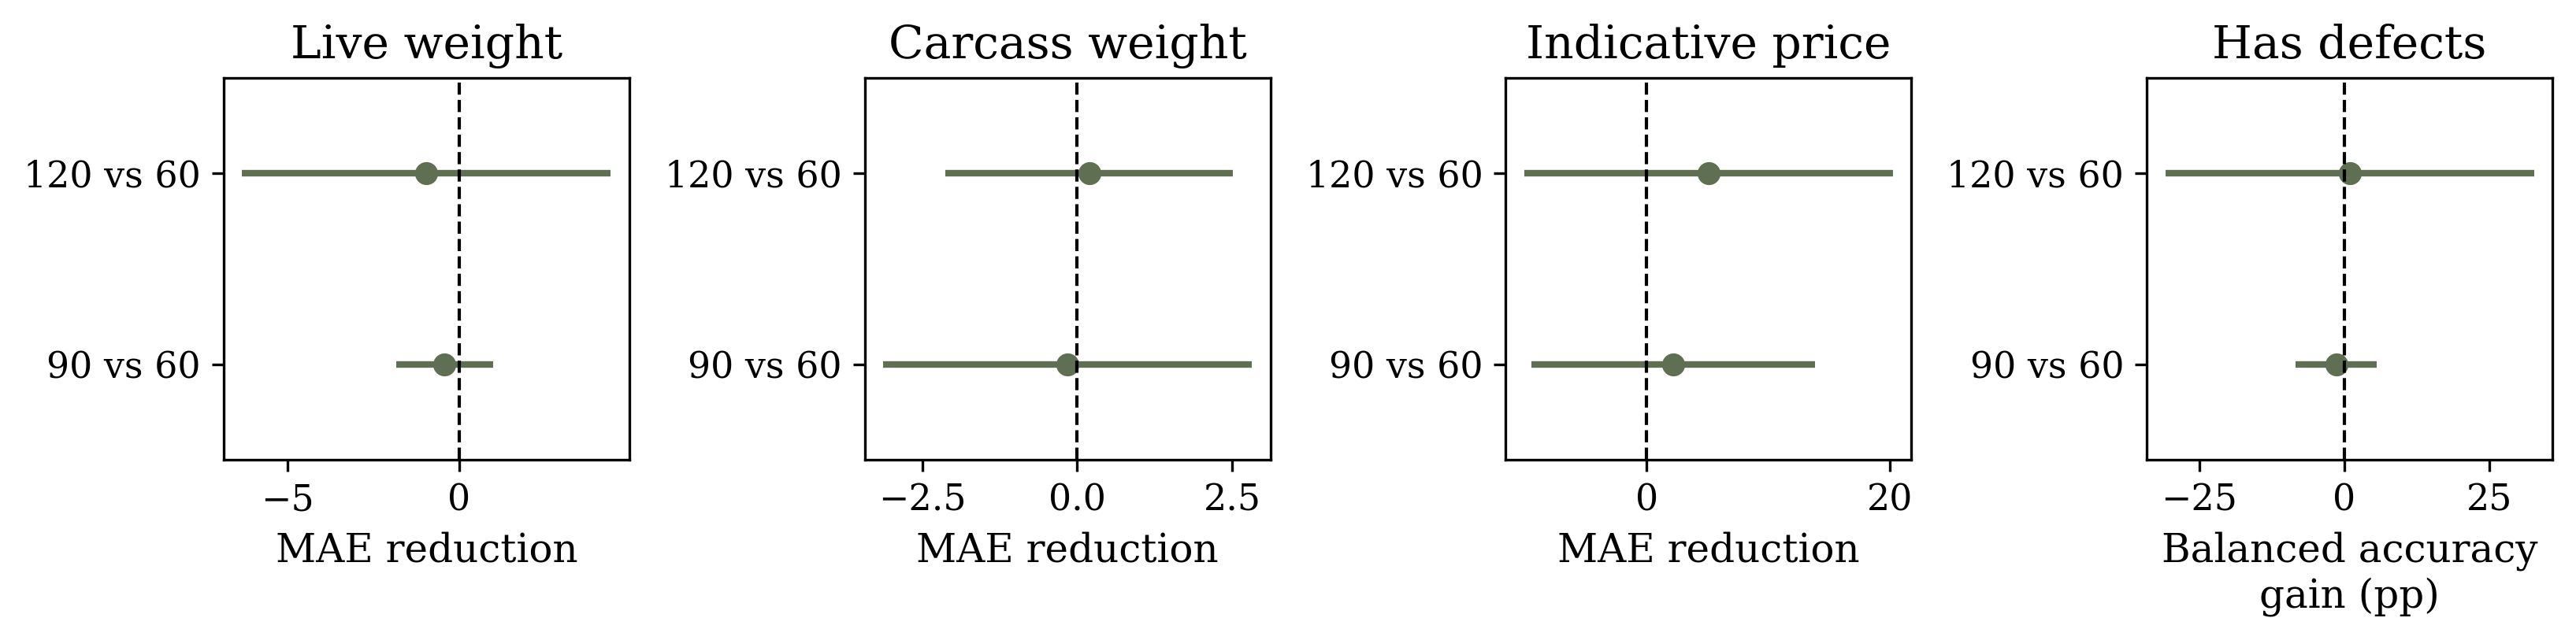

In [ ]:
# comparison intervals: positive values favour longer weather history
animal_types = df_res["animal_type"].unique()
target_order = ["live weight", "carcass weight", "price", "Total number of defects"]

fig, axes = plt.subplots(len(animal_types), 4, figsize=(11, 2.8 * len(animal_types)), squeeze=False)

for i, atype in enumerate(animal_types):
    for ax, target in zip(axes[i], target_order):
        sub = comparison[comparison["animal_type"].eq(atype) & comparison["target"].eq(target)].sort_values("horizon")
        if sub.empty:
            ax.axis("off")
            continue
        scale = 100 if target == "Total number of defects" else 1
        for j, (_, row) in enumerate(sub.iterrows()):
            ax.plot(row["improvement"] * scale, j, "o", color=COLORS[0])
            if np.isfinite([row["lower"], row["upper"]]).all():
                ax.hlines(j, row["lower"] * scale, row["upper"] * scale, color=COLORS[0], linewidth=2)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_yticks([0, 1], ["90 vs 60", "120 vs 60"])
        ax.set_ylim(-0.5, 1.5)
        title = {"price": "Indicative price", "Total number of defects": "Has defects"}.get(target, target.capitalize())
        ax.set_title(title)
        ax.set_xlabel("Balanced accuracy\ngain (pp)" if scale == 100 else "MAE reduction")

plt.tight_layout()
plt.savefig("figs/meat_weather_horizon_intervals.svg", bbox_inches="tight")
plt.savefig("figs/meat_weather_horizon_intervals.png", dpi=300, bbox_inches="tight")
plt.show()

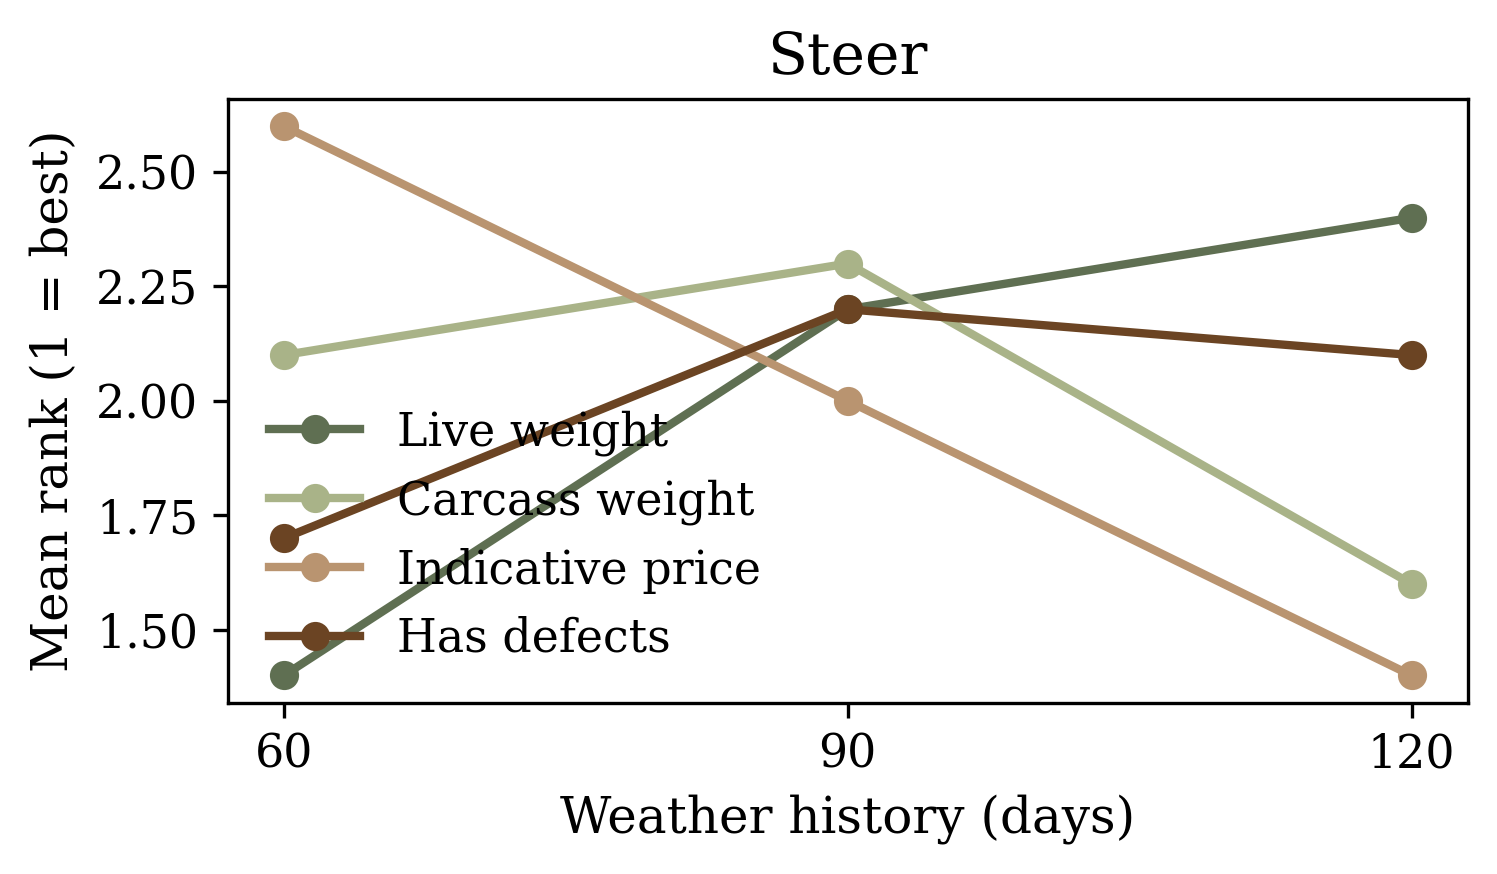

In [ ]:
# mean ranks across folds (descriptive)
fig, axes = plt.subplots(1, len(animal_types), figsize=(5 * len(animal_types), 3), squeeze=False)
palette = COLORS + ["#6B4423"]

for ax, atype in zip(axes.flat, animal_types):
    for target, color in zip(target_order, palette):
        sub = df_res[df_res["animal_type"].eq(atype) & df_res["target"].eq(target)]
        if sub.empty:
            continue
        tab = sub.pivot(index="fold", columns="horizon", values="score")
        ranks = tab.rank(axis=1, ascending=target != "Total number of defects").mean()
        label = {"price": "Indicative price", "Total number of defects": "Has defects"}.get(target, target.capitalize())
        ax.plot(ranks.index, ranks.values, "o-", color=color, label=label)
    ax.set_title(atype.capitalize())
    ax.set_xticks([60, 90, 120])
    ax.set_xlabel("Weather history (days)")
    ax.set_ylabel("Mean rank (1 = best)")
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figs/meat_weather_horizon_ranks.svg", bbox_inches="tight")
plt.savefig("figs/meat_weather_horizon_ranks.png", dpi=300, bbox_inches="tight")
plt.show()